# Module 3 Homework - Seaborn

Using a dataset about Pokemon combat statistic, we will practice data visualization using the seaborn library.  
<img src="https://lh3.googleusercontent.com/v-xCiSuC-wfd033abL8V3YdI4dw-wcAs9nebYt_Y-STHMNupkyE0G7kiwzYLfCwWxEYNDNlHYOwuH8imqr9CAO0s7hwU-qQn7cM=e365-pa-nu-w3840">

In this notebook, we will plot the relationships between different observations of the combat statistics of Pokémon. You will need to import a few packages, including `pandas`, `matplotlib.pyplot`, and `seaborn`. The data is stored in a csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv

Here are the descriptions of this dataset:
- `#` - Pokedex entry number of the Pokemon
- `Name` - name of the Pokemon
- `Type 1` - each Pokemon has a type, this determines weakness/resistance to attacks [referred to as the primary type]
- `Type 2` - some Pokemon are dual type and have 2 [referred to as the secondary type]
- `Total` - sum of all stats that come after this, a general guide to how strong a Pokemon is
- `HP` - hit points, or health, defines how much damage a Pokemon can withstand before fainting
- `Attack` - the base modifier for normal attacks
- `Defense` - the base damage resistance against normal attacks
- `Sp. Atk` - special attack, the base modifier for special attacks
- `Sp. Def` - the base damage resistance against special attacks
- `Speed` - determines which Pokemon attacks first each round
- `Generation` - refers to which grouping/game series the Pokemon was released in
- `Legendary` - a boolean that identifies whether the Pokemon is legendary

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

fp = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv"
pokemon = pd.read_csv(fp)

sns.set_theme(style="whitegrid")
print(f"Rows: {pokemon.shape[0]}, columns: {pokemon.shape[1]}")
print(f"Pokemon without a secondary type: {pokemon['Type 2'].isna().sum()}")
pokemon.head()

Rows: 800, columns: 13
Pokemon without a secondary type: 386


,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


**Data notes:** All 800 rows are retained, including separately listed
forms. A missing `Type 2` means no secondary type; those rows are excluded
only from the secondary-type count plot, not from the other plots.

### Q1: Plot the relationship between Attack and Defense
Create a relationship plot using seaborn's `relplot` function. Plot `Attack` on the x-axis and `Defense` on the y-axis. Include a meaninful title in the plot. After creating the plot, in the markdown cell following, describe the relationship between Attack and Defense in this dataset.

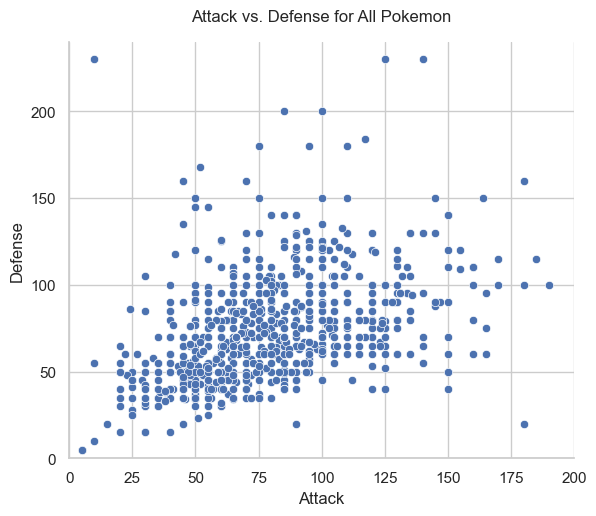

In [2]:
g = sns.relplot(
    data=pokemon,
    x="Attack",
    y="Defense",
    height=5,
    aspect=1.2
)
g.set_axis_labels("Attack", "Defense")
g.set(xlim=(0, 200), ylim=(0, 240))
plt.title("Attack vs. Defense for All Pokemon", pad=15)
plt.show()

**From the plot, I observed** a moderate positive relationship: Pokemon with
higher Attack tend to have higher Defense, but the points are widely spread.
Many Pokemon cluster around Attack 40-110 and Defense 40-100. Some have very
high Defense with low or moderate Attack, so a high value in one statistic
does not guarantee a high value in the other.

### Q2: Use hue to add a third variable
Add color via `hue` to the plot above to map the `HP` (hit point) for each datapoint. You can choose your favorite palette. In addition, add a meaningful title. In the markdown cell following the plot, describe if your visualization suggest that the HP status is associated with a particular regions of Attack/Defense space?

*Bonus*: Repeat with Legendary.  
Compare the overlap between legendary and non-legendary Pokémon. Does the plot suggest that legendary status is associated with particular regions of Attack/Defense space? Support your answer using the visualization.

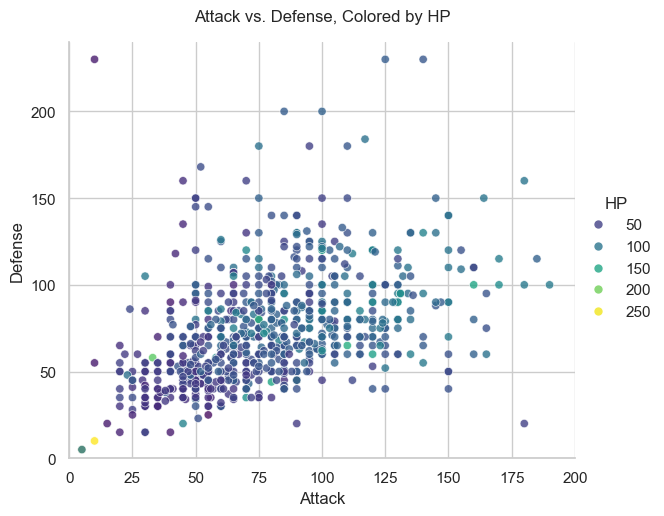

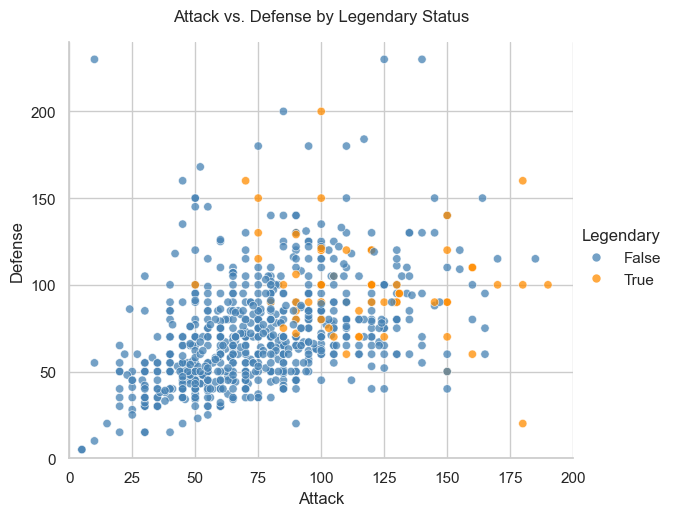

In [3]:
g = sns.relplot(
    data=pokemon,
    x="Attack",
    y="Defense",
    hue="HP",
    palette="viridis",
    alpha=0.8,
    height=5,
    aspect=1.2
)
g.set_axis_labels("Attack", "Defense")
g.set(xlim=(0, 200), ylim=(0, 240))
plt.title("Attack vs. Defense, Colored by HP", pad=15)
plt.show()

# Bonus: use the same axes to compare legendary status.
g = sns.relplot(
    data=pokemon,
    x="Attack",
    y="Defense",
    hue="Legendary",
    hue_order=[False, True],
    palette={False: "steelblue", True: "darkorange"},
    alpha=0.75,
    height=5,
    aspect=1.2
)
g.set_axis_labels("Attack", "Defense")
g.set(xlim=(0, 200), ylim=(0, 240))
plt.title("Attack vs. Defense by Legendary Status", pad=15)
plt.show()

**From the HP plot, I observed** that higher HP often appears at moderate to
high Attack, but the colors overlap across much of the plot. There is no
single region containing all high-HP Pokemon: a bright point appears
near the lower-left corner, showing that very high HP can occur with very
low Attack and Defense.

**For the Legendary bonus,** legendary Pokemon appear more often toward the
upper-right, especially around Attack 100-150 and Defense 90-120. However,
many non-legendary Pokemon occupy that same area, and some legendary Pokemon
have relatively low Attack or Defense. Legendary status is associated with
higher values overall, but these two statistics do not separate the groups
completely.

### Q3: Reduce overplotting by changing visualization
Create two `relplot` scatter plots of `Sp. Atk` vs. `Sp. Def`:

1. A standard scatter plot using all Pokémon.
2. A second plot that reduces overplotting by changing transparency (`alpha`) and marker size (`s`).

Use the same axis variables for both plots. Compare the two plots and explain which version makes dense regions easier to see and why.

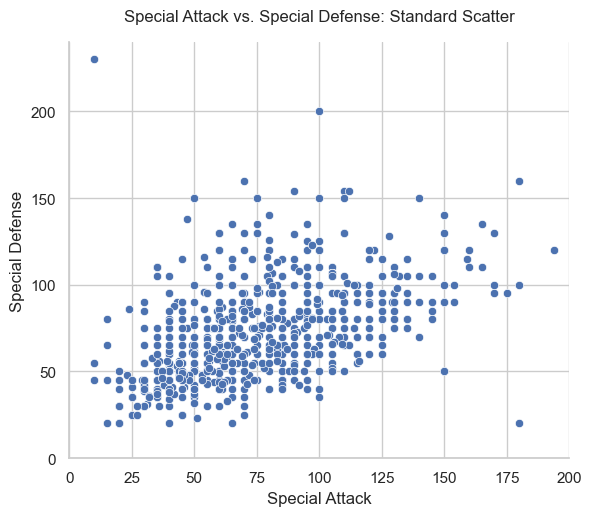

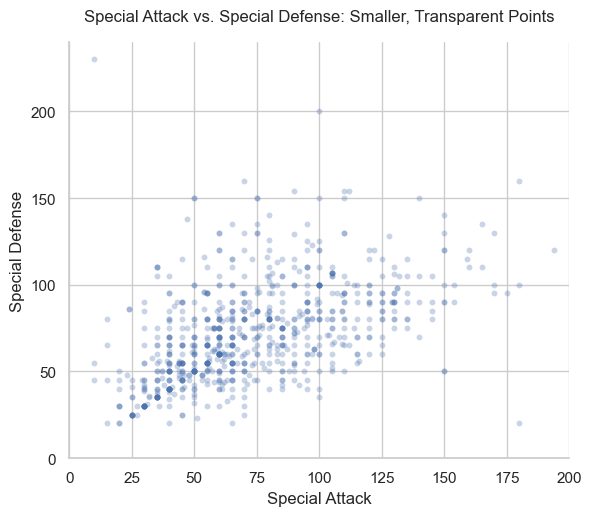

In [4]:
g = sns.relplot(
    data=pokemon,
    x="Sp. Atk",
    y="Sp. Def",
    height=5,
    aspect=1.2
)
g.set_axis_labels("Special Attack", "Special Defense")
g.set(xlim=(0, 200), ylim=(0, 240))
plt.title("Special Attack vs. Special Defense: Standard Scatter", pad=15)
plt.show()

g = sns.relplot(
    data=pokemon,
    x="Sp. Atk",
    y="Sp. Def",
    alpha=0.3,
    s=18,
    linewidth=0,
    height=5,
    aspect=1.2
)
g.set_axis_labels("Special Attack", "Special Defense")
g.set(xlim=(0, 200), ylim=(0, 240))
plt.title("Special Attack vs. Special Defense: Smaller, Transparent Points", pad=15)
plt.show()

**From the plots, I observed** a positive relationship between Special Attack
and Special Defense, with many observations in the lower-to-middle ranges.
The second plot makes crowded regions easier to see because smaller points
cover less space and overlapping transparent points become darker. Both
plots contain all 800 Pokemon and use the same axis limits, so the difference
comes from marker styling rather than removing observations.

### Q4: Plot the relationship between Attack and Total using a hexbin plot
Create a hexbin plot using seaborn's `jointplot` function. Plot `Attack` on the x-axis and `Total` on the y-axis. You can choose the gridsize. Include a title for the plot. After generating the plot, in the markdown cell following the plot explain what relationship the hexbin plot displays between the  `Attack` and `Total` columns?

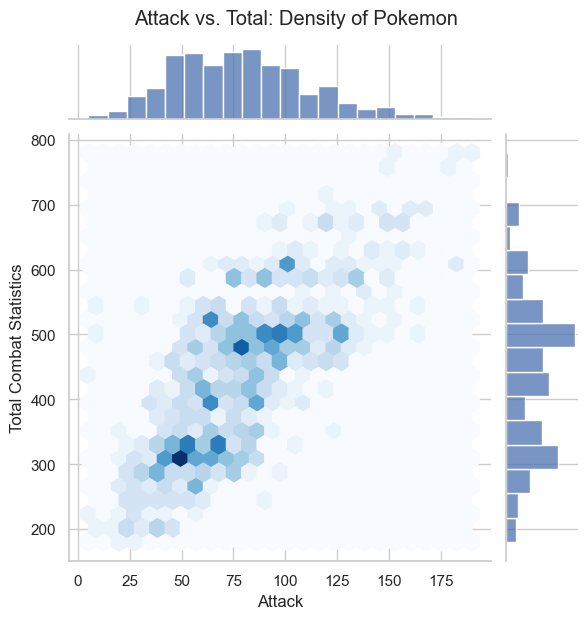

In [5]:
g = sns.jointplot(
    data=pokemon,
    x="Attack",
    y="Total",
    kind="hex",
    gridsize=25,
    cmap="Blues",
    height=6
)
g.set_axis_labels("Attack", "Total Combat Statistics")
g.fig.suptitle("Attack vs. Total: Density of Pokemon", y=1.03)
plt.show()

**From the plot, I observed** a clear positive relationship: Pokemon with
higher Attack generally have higher Total values. Darker hexagons show
regions with more Pokemon, while the marginal histograms summarize each
statistic separately. There is still variation in Total at a given Attack
value because Total also includes five other statistics. Since Attack is
itself part of Total, part of this association follows directly from how
Total is calculated.

### Q5: Investigate density with a second hexbin plot
Create a second `jointplot(kind="hex")`, this time comparing `Sp. Atk` and `Sp. Def`. Choose an appropriate `gridsize`.

Then create the plot again with a noticeably different `gridsize`. Explain how changing `gridsize` changes what you can see about the density of observations. Identify the region containing the greatest concentration of Pokémon.

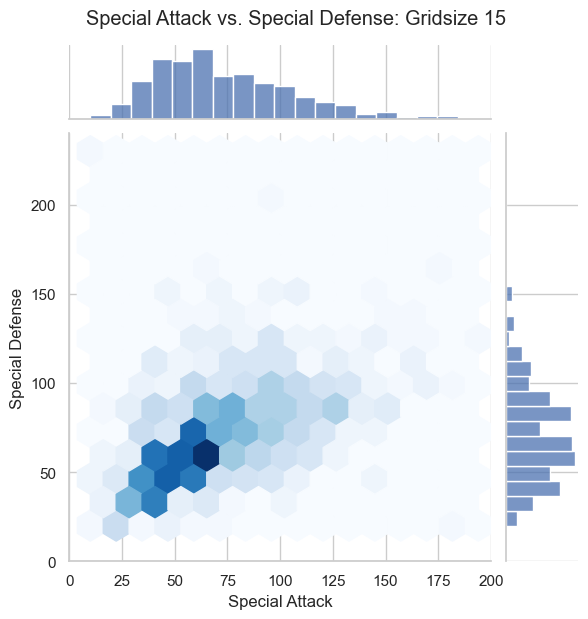

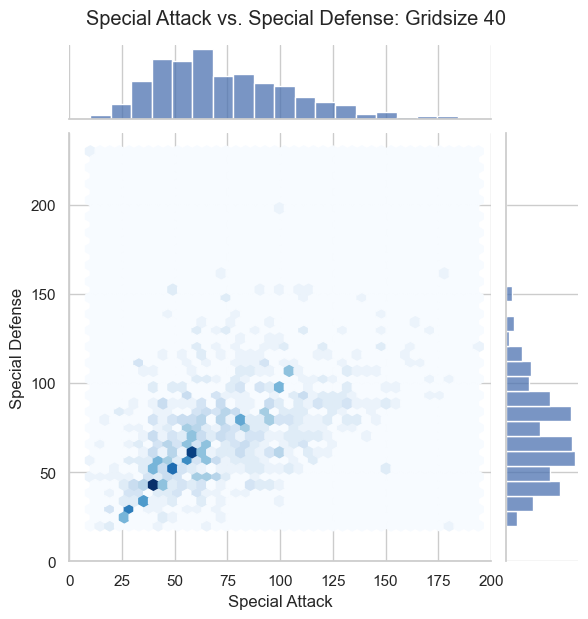

In [6]:
g = sns.jointplot(
    data=pokemon,
    x="Sp. Atk",
    y="Sp. Def",
    kind="hex",
    gridsize=15,
    cmap="Blues",
    height=6
)
g.set_axis_labels("Special Attack", "Special Defense")
g.ax_joint.set(xlim=(0, 200), ylim=(0, 240))
g.fig.suptitle("Special Attack vs. Special Defense: Gridsize 15", y=1.03)
plt.show()

g = sns.jointplot(
    data=pokemon,
    x="Sp. Atk",
    y="Sp. Def",
    kind="hex",
    gridsize=40,
    cmap="Blues",
    height=6
)
g.set_axis_labels("Special Attack", "Special Defense")
g.ax_joint.set(xlim=(0, 200), ylim=(0, 240))
g.fig.suptitle("Special Attack vs. Special Defense: Gridsize 40", y=1.03)
plt.show()

**From the plots, I observed** that a gridsize of 15 creates larger hexagons
that combine nearby observations and make the broad concentration easier
to identify. A gridsize of 40 creates smaller hexagons that reveal local
clusters and gaps, but the density looks more fragmented. The greatest
concentration is in the lower-to-middle region, roughly Special Attack
35-80 and Special Defense 35-85: the darkest coarse bin is near (65, 59),
while the darkest fine bin is near (40, 43). Each plot scales its shading
to its own bin counts, so equal shades across the two plots do not
necessarily represent equal numbers of Pokemon.

### Q6: Create two categorical plots for Pokemon types. `Type 1` and `Type 2` .
For each plot, the unique values of `Type 1` or `Type 2` should be plotted along the y-axis, and the counts of Pokemon should be on the x-axis. Use the color red for the `Type 1` plot and blue for the `Type 2` plot. After the two plots are displayed, insert a markdown cell to write your findings: Which are the most common `Type 1` and `Type 2` Pokemons, and which are the most rare ones?

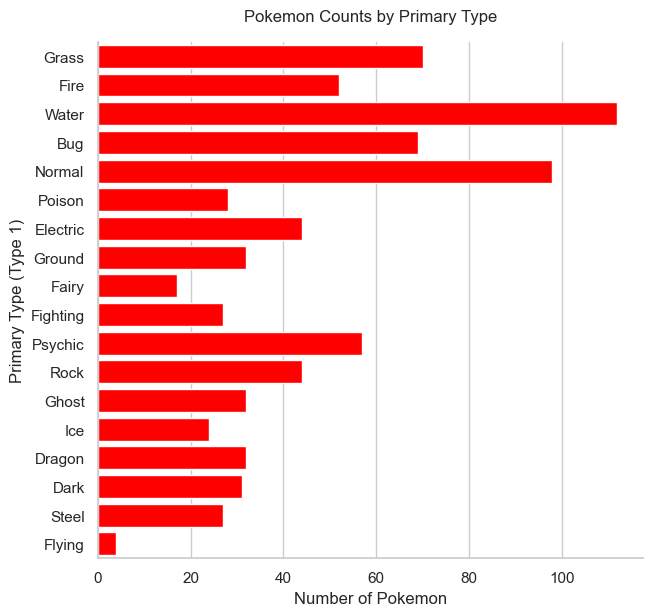

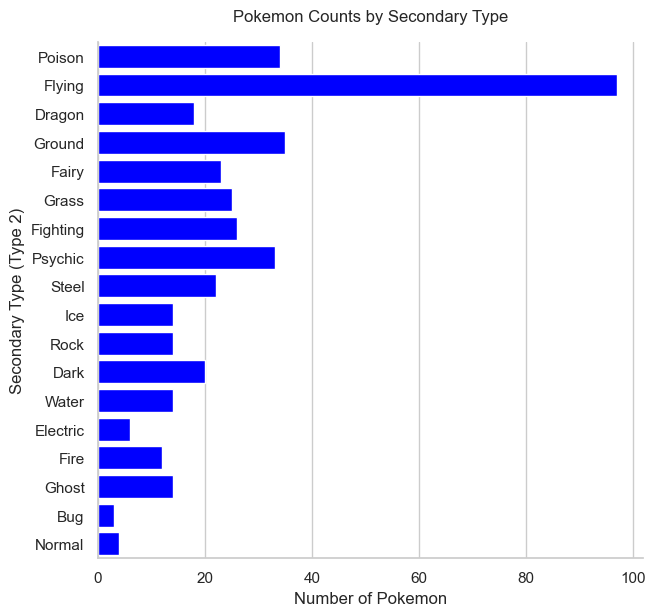

,Type 1 count,Type 2 count
Bug,69,3
Dark,31,20
Dragon,32,18
Electric,44,6
Fairy,17,23
Fighting,27,26
Fire,52,12
Flying,4,97
Ghost,32,14
Grass,70,25


In [7]:
g = sns.catplot(
    data=pokemon,
    y="Type 1",
    kind="count",
    color="red",
    saturation=1,
    height=6,
    aspect=1.1
)
g.set_axis_labels("Number of Pokemon", "Primary Type (Type 1)")
plt.title("Pokemon Counts by Primary Type", pad=15)
plt.show()

# Only dual-type Pokemon have a Type 2 category to count.
g = sns.catplot(
    data=pokemon.dropna(subset=["Type 2"]),
    y="Type 2",
    kind="count",
    color="blue",
    saturation=1,
    height=6,
    aspect=1.1
)
g.set_axis_labels("Number of Pokemon", "Secondary Type (Type 2)")
plt.title("Pokemon Counts by Secondary Type", pad=15)
plt.show()

type_counts = pd.DataFrame({
    "Type 1 count": pokemon["Type 1"].value_counts(),
    "Type 2 count": pokemon["Type 2"].value_counts()
})
type_counts

**From the plots, I observed** that Water is the most common primary type
(112 Pokemon), followed by Normal (98), while Flying is the rarest primary
type (4). Flying is the most common secondary type (97), while Bug is the
rarest secondary type (3), followed by Normal (4). The Type 2 plot counts
only the 414 rows with a secondary type; the other 386 Pokemon have no
secondary type and are not included in those bars. These counts refer to
dataset rows, including separately listed forms.

### Q7: Order a categorical count plot
Create a `catplot(kind="count")` for `Type 1`. Plot Pokémon types on the **y-axis** and counts on the **x-axis**. Order the categories from most common to least common using `value_counts().index`, and add meaningful axis labels.

After plotting, explain how ordering the categories can make the graph easier to interpret compared to an unordered count plot.


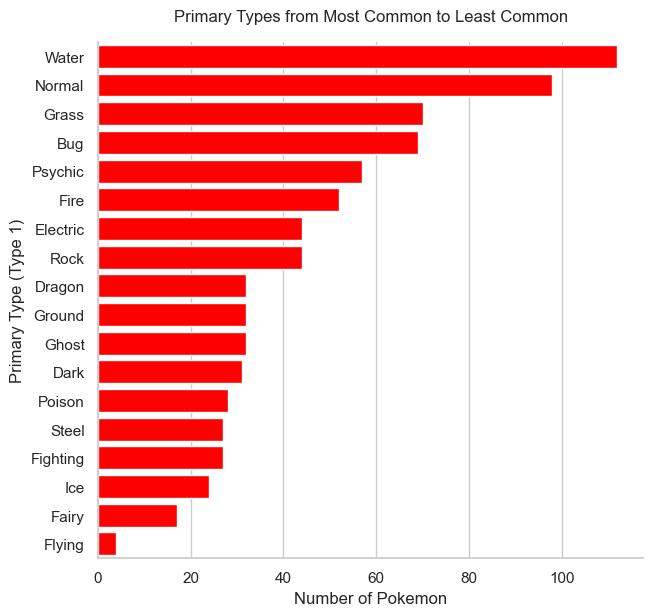

In [8]:
g = sns.catplot(
    data=pokemon,
    y="Type 1",
    kind="count",
    order=pokemon["Type 1"].value_counts().index,
    color="red",
    saturation=1,
    height=6,
    aspect=1.1
)
g.set_axis_labels("Number of Pokemon", "Primary Type (Type 1)")
plt.title("Primary Types from Most Common to Least Common", pad=15)
plt.show()

**From the plot, I observed** that ordering the bars puts the most common
types at the top and the rarest types at the bottom. This makes Water,
Normal, and Grass easy to identify as the three most common types, and
Flying as the least common. Compared with the unordered plot, I can read
the ranking directly without searching back and forth between bars;
sorting changes the presentation but not the counts.

### Q8: Compare Attack distributions among common Pokémon types
Identify the five most common `Type 1` categories. Filter the dataframe to those five types, then create a Seaborn `catplot(kind="box")` with `Type 1` and `Attack`.

Use the plot to compare the center and spread of Attack values. Which types appear to have higher median Attack? Which show the greatest variability?


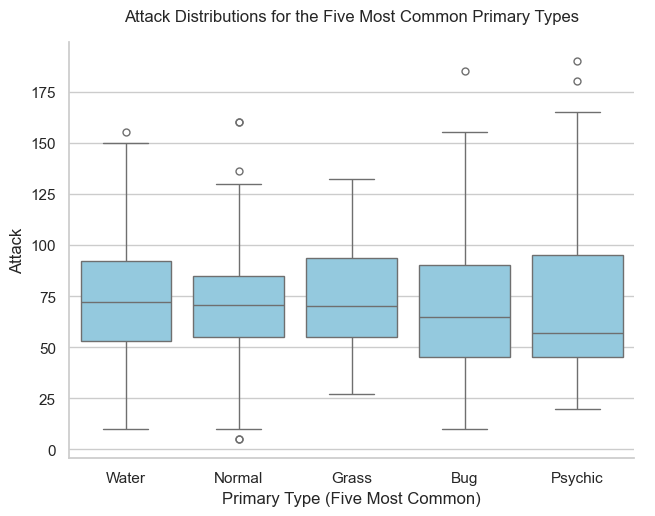

,min,25%,50%,75%,max
Type 1,,,,,
Water,10.0,53.0,72.0,92.0,155.0
Normal,5.0,55.0,70.5,85.0,160.0
Grass,27.0,55.0,70.0,93.5,132.0
Bug,10.0,45.0,65.0,90.0,185.0
Psychic,20.0,45.0,57.0,95.0,190.0


In [9]:
top_five_types = pokemon["Type 1"].value_counts().head(5).index
common_pokemon = pokemon[pokemon["Type 1"].isin(top_five_types)]

g = sns.catplot(
    data=common_pokemon,
    x="Type 1",
    y="Attack",
    kind="box",
    order=top_five_types,
    color="skyblue",
    height=5,
    aspect=1.3
)
g.set_axis_labels("Primary Type (Five Most Common)", "Attack")
plt.title("Attack Distributions for the Five Most Common Primary Types", pad=15)
plt.show()

common_pokemon.groupby("Type 1")["Attack"].describe().loc[
    top_five_types, ["min", "25%", "50%", "75%", "max"]
]

**From the plot, I observed** that the five most common primary types are
Water, Normal, Grass, Bug, and Psychic. Water has the highest median Attack
(72), followed closely by Normal (70.5) and Grass (70); Bug (65) and Psychic
(57) have lower medians. Psychic has the widest box, with an interquartile
range of 50, followed by Bug at 45, so Psychic has the greatest variability
among the middle 50% of observations. Bug has the largest full range
(10-185, a span of 175), slightly wider than Psychic (20-190, a span of 170).
The boxes overlap substantially, so these types cannot be cleanly
distinguished by Attack alone.

### Q9 and Q10: Your own questions
Come up with two additional questions that can be answered visually using the Pokémon dataset. Your questions should use Seaborn and should not simply repeat Q1–Q8. For each question:

* State the data question clearly
* Choose an appropriate Seaborn visualization. Use different visualization strategies across your two questions.
* Include a meaningful title and informative axes labels
* Write 2–3 sentences interpreting the visualization

### Q9: Which generations have the most and fewest Pokemon in this dataset?

A categorical count plot compares the number of Pokemon in each
generation.

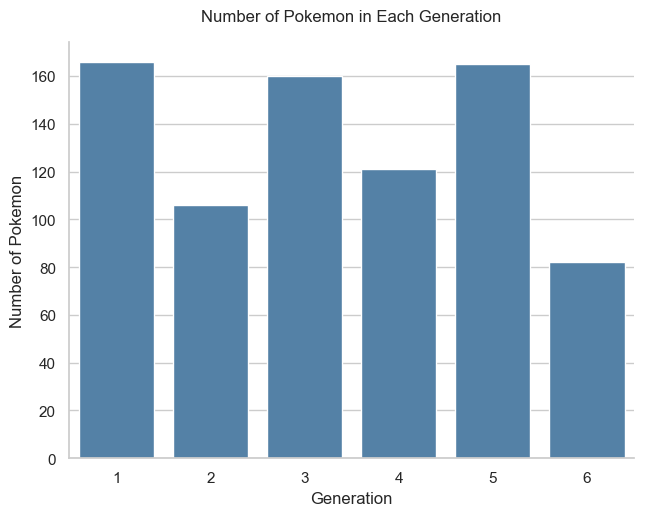

Generation
1    166
2    106
3    160
4    121
5    165
6     82
Name: count, dtype: int64

In [10]:
g = sns.catplot(
    data=pokemon,
    x="Generation",
    kind="count",
    order=sorted(pokemon["Generation"].unique()),
    color="steelblue",
    height=5,
    aspect=1.3
)
g.set_axis_labels("Generation", "Number of Pokemon")
plt.title("Number of Pokemon in Each Generation", pad=15)
plt.show()

pokemon["Generation"].value_counts().sort_index()

**From the plot, I observed** that generations 1 and 5 have the largest
overall counts (166 and 165), while generation 6 has the smallest (82).
The counts do not steadily increase or decrease with generation:
generation 3 also has a high count (160), while generations 2 and 4
have 106 and 121 rows.
These counts describe rows in this dataset, including separately listed
forms, rather than the number of unique species originally released.

### Q10: Do Pokemon with higher Attack also tend to have higher Special Attack?

A regression plot shows the overall linear trend along with the
individual observations.

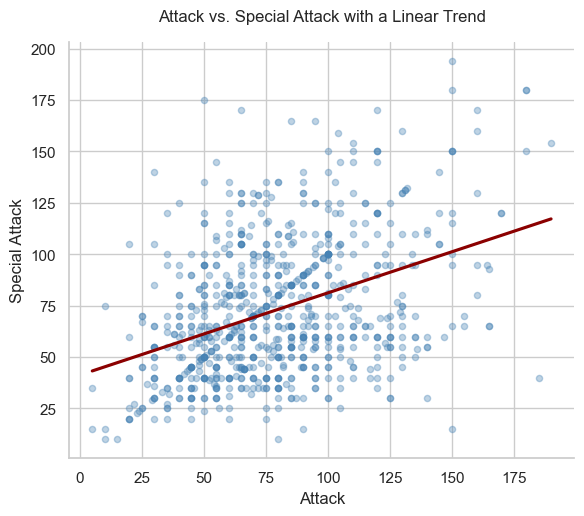

In [11]:
g = sns.lmplot(
    data=pokemon,
    x="Attack",
    y="Sp. Atk",
    ci=None,
    scatter_kws={"alpha": 0.35, "s": 20, "color": "steelblue"},
    line_kws={"color": "darkred"},
    height=5,
    aspect=1.2
)
g.set_axis_labels("Attack", "Special Attack")
plt.title("Attack vs. Special Attack with a Linear Trend", pad=15)
plt.show()

**From the plot, I observed** an upward-sloping regression line, suggesting
that higher Attack is generally associated with higher Special Attack.
However, the wide scatter includes Pokemon with high Attack and low
Special Attack, so strength in normal attacks does not guarantee
strength in special attacks. The line summarizes an association in
this dataset and does not show that one statistic causes the other.

##Bonus Questions

### B1: Map both hue and point size
Create a `relplot` with `Attack` on the x-axis and `Defense` on the y-axis. Map `Speed` to `hue` and `Total` to `size`. Choose a reasonable `sizes=(min, max)` range so that the points remain readable.

Describe what information is represented by position, color, and point size. What pattern, if any, do you notice among Pokémon with high `Total` values?


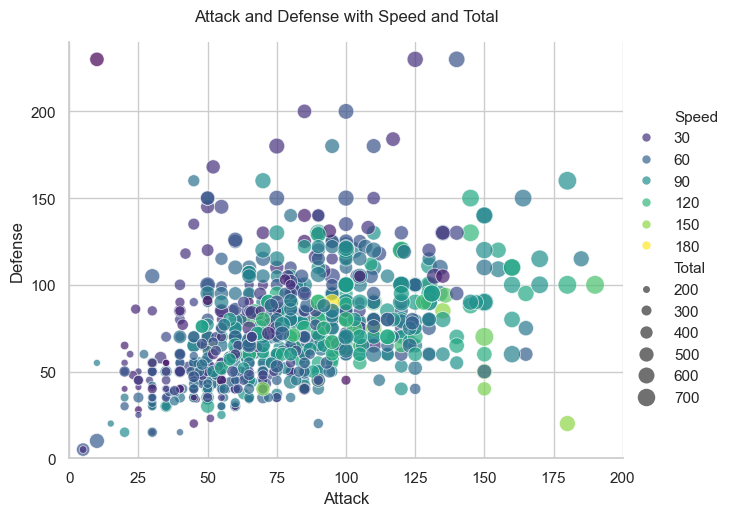

In [12]:
g = sns.relplot(
    data=pokemon,
    x="Attack",
    y="Defense",
    hue="Speed",
    size="Total",
    sizes=(20, 180),
    palette="viridis",
    alpha=0.7,
    height=5,
    aspect=1.3
)
g.set_axis_labels("Attack", "Defense")
g.set(xlim=(0, 200), ylim=(0, 240))
plt.title("Attack and Defense with Speed and Total", pad=15)
plt.show()

**From the plot, I observed** that horizontal position represents Attack,
vertical position represents Defense, color represents Speed, and
marker area represents Total. Larger markers appear more often toward
higher Attack and Defense, although some also occur at moderate values
because Total includes HP, Special Attack, Special Defense, and Speed
as well. The large markers have a range of colors, so a high Total
does not necessarily mean the highest Speed.

### B2: Subsample the dataset
Use pandas `.sample()` to randomly select **200 Pokémon**, then create a `relplot` of `Attack` vs. `Defense` from the sample. Use a random seed by setting `random_state=1` so that your result is reproducible. Compare this plot with your Q1 plot that used the full dataset.

What information can be lost when subsampling? What is one reason subsampling can still be useful when working with very large datasets?


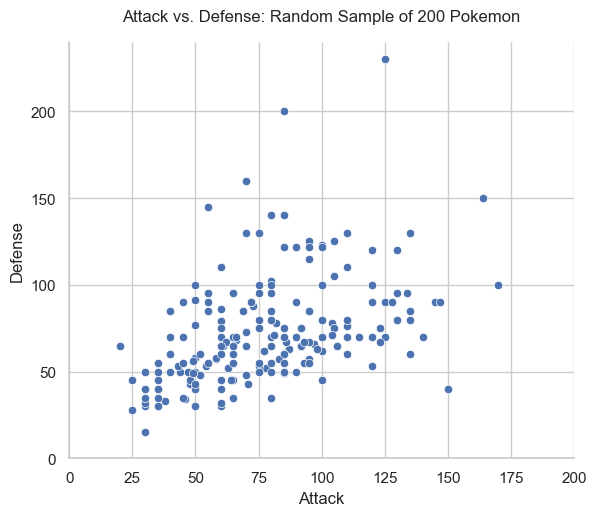

In [13]:
pokemon_sample = pokemon.sample(n=200, random_state=1)

g = sns.relplot(
    data=pokemon_sample,
    x="Attack",
    y="Defense",
    height=5,
    aspect=1.2
)
g.set_axis_labels("Attack", "Defense")
g.set(xlim=(0, 200), ylim=(0, 240))
plt.title("Attack vs. Defense: Random Sample of 200 Pokemon", pad=15)
plt.show()

**From the plot, I observed** that the sample keeps the broad positive
relationship from Q1 but has fewer overlapping points. It loses some
extreme observations: the largest sampled Attack is 170, compared
with 190 in the full dataset. Subsampling can miss rare groups,
outliers, and fine details of the density, but it can reduce plotting
time and clutter for very large datasets. Using `random_state=1`
makes this sample reproducible, and using the same axis limits as Q1
makes the comparison fair.

### B3: Compare groups with a multi-panel relationship plot
Use `sns.relplot()` to compare `Attack` vs. `Defense` across Pokémon generations. Set `col="Generation"` so that each generation is displayed in a separate panel. Use `hue="Legendary"` to distinguish legendary from non-legendary Pokémon.

After plotting, identify one similarity and one difference you observe across generations. How can the implementation of multi-panel plot make it easier to interpret compare to  placing every group on one set of axes?


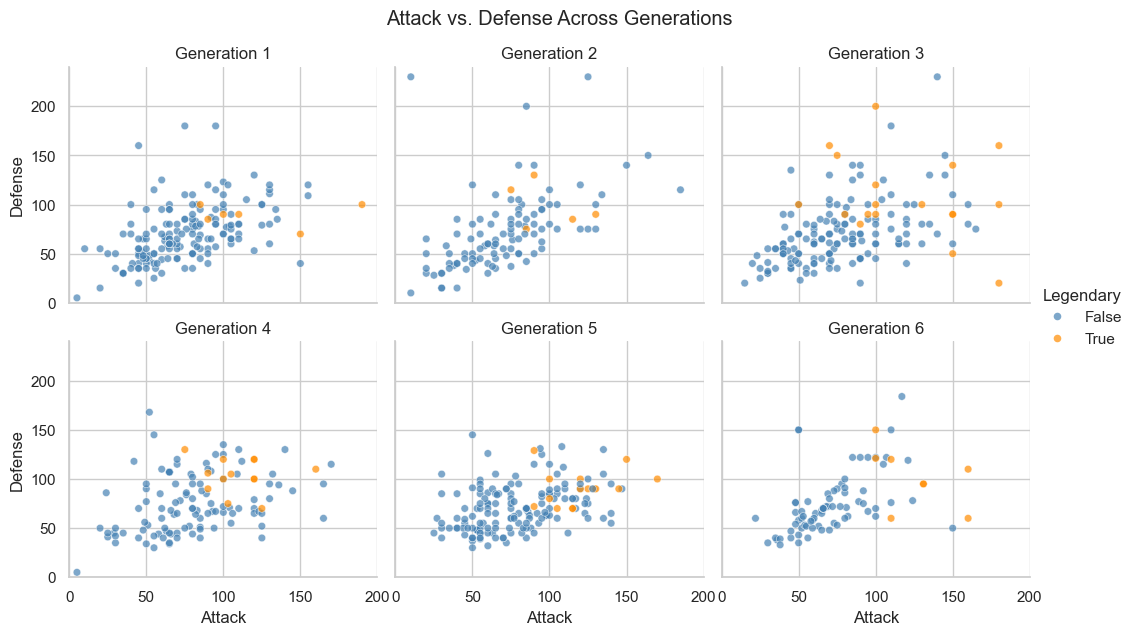

In [14]:
g = sns.relplot(
    data=pokemon,
    x="Attack",
    y="Defense",
    col="Generation",
    col_order=sorted(pokemon["Generation"].unique()),
    col_wrap=3,
    hue="Legendary",
    hue_order=[False, True],
    palette={False: "steelblue", True: "darkorange"},
    alpha=0.7,
    s=30,
    height=3.2,
    aspect=1.1
)
g.set_axis_labels("Attack", "Defense")
g.set_titles("Generation {col_name}")
g.set(xlim=(0, 200), ylim=(0, 240))
g.fig.subplots_adjust(top=0.90)
g.fig.suptitle("Attack vs. Defense Across Generations", y=0.99)
plt.show()

**From the panels, I observed** that every generation has many Pokemon
in the moderate Attack/Defense region, with substantial overlap between
legendary and non-legendary Pokemon. One difference is that generations
2 and 3 contain Defense values of 230, whereas generation 5 reaches
only 145. Separating the generations while keeping the same axes and
color mapping makes their ranges and unusual observations easier to
compare and reduces overlap between groups. Panel densities should
be interpreted with care because generations contain different numbers
of rows in this dataset.

### Lecture methods used

- `M03_Colab07_seaborn_catplot_relplot.ipynb`: `relplot`, `hue`, `size`,
  categorical counts, box plots (class exercise CL7.1), axis labels,
  and `value_counts().index` ordering.
- `M03_Colab08_relplot_hexbin.ipynb`: transparency, marker size,
  `jointplot(kind="hex")`, subsampling, and panels.
- `M03_Colab08_relplot.ipynb`: `lmplot` and interpreting a linear trend.